## Notebook by Karol Rejek

In [236]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [237]:
import matplotlib.pyplot as plt
import seaborn as sns

In [238]:
import pandas as pd
import numpy as np
from pathlib import Path

base_path = Path('content/drive/MyDrive/DataSets')
data_path = '/content/drive/MyDrive/DataSets/titanic.csv'
titanic_df = pd.read_csv(data_path, index_col='PassengerId')

def count_outliers_iqr(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    mask = (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)
    return mask.sum()

titanic_df['SocialStatus'] = titanic_df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()

socialstatus_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
titanic_df['SocialStatus'] = titanic_df['SocialStatus'].replace(socialstatus_mapping)

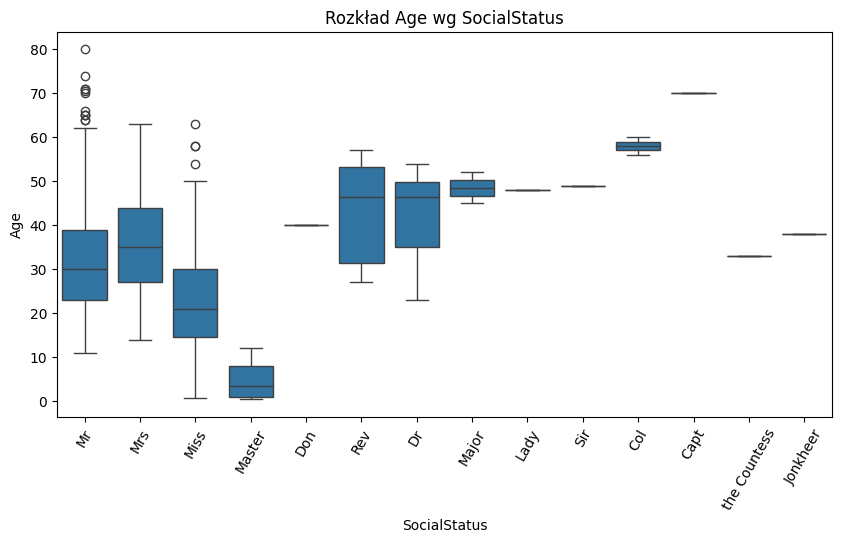

In [239]:
plt.figure(figsize=(10,5))
sns.boxplot(data=titanic_df, x='SocialStatus', y='Age')
plt.xticks(rotation=60)
plt.title('Rozkład Age wg SocialStatus')
plt.show()

In [240]:
titanic_df['Age'] = titanic_df.groupby('SocialStatus')['Age'].transform(lambda x: x.fillna(x.median()))

### Imputacja wieku (`Age`) na podstawie tytułu (`Title`)

Brakujące wartości w kolumnie `Age` uzupełniłem medianą wieku wyliczoną **osobno dla każdej grupy `Title`** (np. Mr, Mrs, Miss, Master, Dr, Rev...).
Można zauwarzyć że w danych kolumana `Name` zawiera takie inforamacjie jak: imię, nazwisko, status społeczny czy przezwisko. Wydobycie informacji z kolumny `Name` o statusie społecznym danego pasarzera pozwala oszacować wiek w brakujących komurkach w kolumnie `Age` na podstawie wyliczenia mediany z dla danego statusu społecznego danej osoby. Z tego powodu wyodrębniłem status społeczny danje odoby do kolumny `Title` w celu lepszego pogrupowania do wyliczenia mediany. Przed wyliczeniem mediany `Age` ujednoliciłem tożsame warianty językowe tytułów (`Mlle`→`Miss`, `Ms`→`Miss`, `Mme`→`Mrs`), aby nie tworzyć sztucznie rozdrobnionych grup.

In [241]:
titanic_df.groupby(['Pclass', titanic_df['Cabin'].isna()])['Survived'].mean()

Pclass  Cabin
1       False    0.664773
        True     0.475000
2       False    0.812500
        True     0.440476
3       False    0.500000
        True     0.235908
Name: Survived, dtype: float64

Decyduję się na usunięcie kolumny `Name`, ponieważ w surowej, tekstowej formie każda wartość jest praktycznie unikalna dla danego pasażera, co nie wnosi żadnej użytecznej informacji predykcyjnej dla modelu, a mogłoby jedynie zwiększyć wymiarowość danych bez korzyści. Najważniejsza informacja zawarta w tej kolumnie — status społeczny pasażera — została już wyekstrahowana do kolumny `SocialStatus`, więc `Name` w dużej mierze duplikuje to, co model może uzyskać z innych, lepiej ustrukturyzowanych cech. Rozważałem również wykorzystanie `Name` do identyfikacji rodzin (np. w połączeniu z `Ticket`, aby oszacować przeżywalność w obrębie rodziny), jednak ostatecznie zrezygnowałem z tego podejścia w ramach tej analizy, co czyni tę kolumnę zbędną w finalnym zbiorze.

In [242]:
titanic_df = titanic_df.drop(columns=['Name'])

### Kodowanie `SocialStatus`

Ponieważ `SocialStatus` jest zmienną nominalną, to do kodowania stosuję metodę **one-hot** (`pd.get_dummies`). `SocialStatus` wszystkie oryginalne kategorie po wcześniejszym ujednoliceniu językowych wariantów: (Mlle=>Miss, Ms=>Miss, Mme=>Mrs), ponieważ nawet rzadkie tytuły (np. Dr, Rev, Col) mogą nieść istotną informację o statusie społecznym pasażera, wpływającą na przeżywalność. Zastosowanie one-hot encoding nie wprowadza sztucznej kolejności między kategoriami, w przeciwieństwie do kodowania porządkowego, które błędnie sugerowałoby, że jedna kategoria jest "większa" od drugiej.

In [243]:
# Liczebność kategorii SocialStatus
titanic_df['SocialStatus'].value_counts()

,count
SocialStatus,
Mr,517
Miss,185
Mrs,126
Master,40
Dr,7
Rev,6
Col,2
Major,2
Don,1


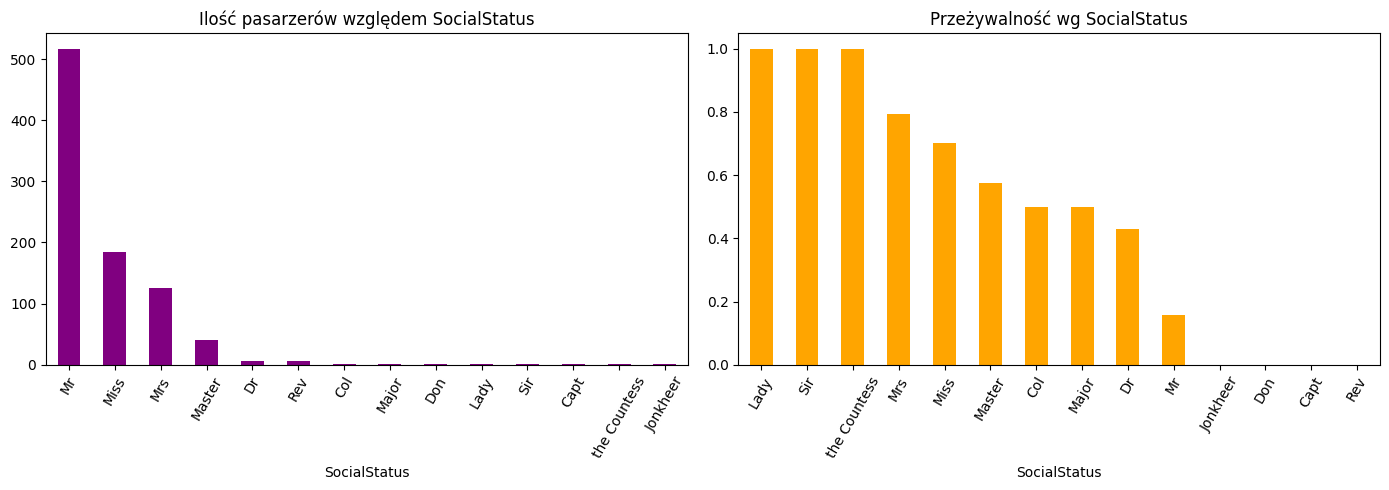

In [244]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
titanic_df['SocialStatus'].value_counts().plot(kind='bar', ax=axes[0], color='purple')
axes[0].set_title('Ilość pasarzerów względem SocialStatus')
axes[0].tick_params(axis='x', rotation=60)

titanic_df.groupby('SocialStatus')['Survived'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Przeżywalność wg SocialStatus')
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

In [245]:
titanic_df = pd.get_dummies(titanic_df, columns=['SocialStatus'], prefix='SocialStatus')

### Rekonstrukcja kolumn SibSp + Parch

Sprawdziłem osobno związek `SibSp` i `Parch` z przeżywalnością przed ich połączeniem. Obie kolumny mają podobny, nieliniowy kształt - wzrost przy małej liczbie towarzyszy, spadek przy większej (szczyty: SibSp=1 => 53,6%, Parch=3 => 60,0%), przy czym wartości dla większych liczb opierają się na małych próbkach. Podobieństwo wzorców uzasadnia połączenie obu kolumn w jedną cechę.

In [246]:
titanic_df.groupby('SibSp')['Survived'].mean()

,Survived
SibSp,
0,0.345395
1,0.535885
2,0.464286
3,0.250000
4,0.166667
5,0.000000
8,0.000000


In [247]:
titanic_df.groupby('Parch')['Survived'].mean()

,Survived
Parch,
0,0.343658
1,0.550847
2,0.500000
3,0.600000
4,0.000000
5,0.200000
6,0.000000


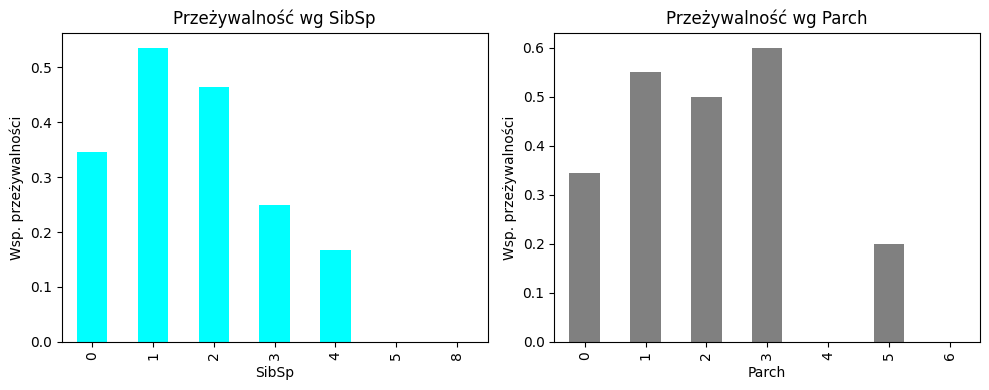

In [248]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

titanic_df.groupby('SibSp')['Survived'].mean().plot(kind='bar', ax=axes[0], color='cyan')
axes[0].set_title('Przeżywalność wg SibSp')
axes[0].set_ylabel('Wsp. przeżywalności')

titanic_df.groupby('Parch')['Survived'].mean().plot(kind='bar', ax=axes[1], color='gray')
axes[1].set_title('Przeżywalność wg Parch')
axes[1].set_ylabel('Wsp. przeżywalności')

plt.tight_layout()
plt.show()

Zbadałem przeżywalność względem `FamilySize` (`SibSp + Parch + 1`) oraz liczebności poszczególnych grup. Zależność ma kształt odwróconej paraboli - szczyt 72,4% przy `FamilySize=4`, a spadek widoczny jest zarówno dla mniejszych, jak i większych wartości. Grupy 7, 8 i 11 liczą zaledwie 12, 6 i 7 obserwacji, co jest niewiarygodne statystycznie i uzasadnia zbinowanie tej zmiennej.

In [249]:
family_size = titanic_df['SibSp'] + titanic_df['Parch'] + 1

titanic_df.groupby(family_size)['Survived'].mean()

,Survived
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


In [250]:
family_size.value_counts().sort_index()

,count
1,537
2,161
3,102
4,29
5,15
6,22
7,12
8,6
11,7


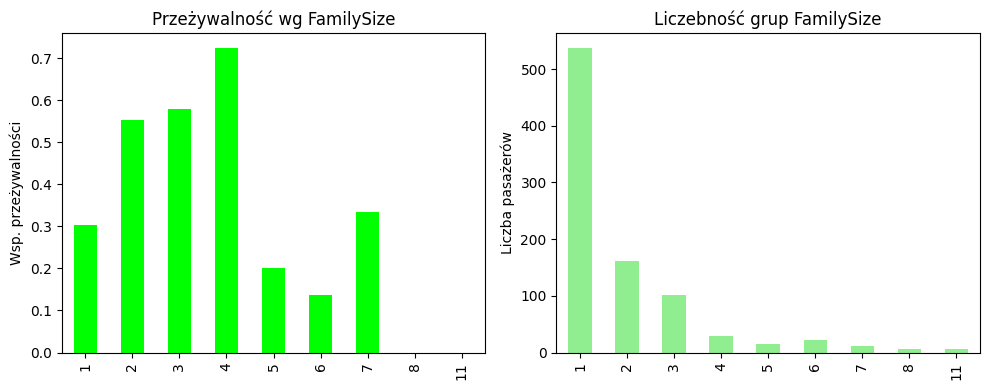

In [251]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

titanic_df.groupby(family_size)['Survived'].mean().plot(kind='bar', ax=axes[0], color='lime')
axes[0].set_title('Przeżywalność wg FamilySize')
axes[0].set_ylabel('Wsp. przeżywalności')

family_size.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Liczebność grup FamilySize')
axes[1].set_ylabel('Liczba pasażerów')

plt.tight_layout()
plt.show()

Zbadałem zależność między `FamilySize` a przeżywalnością i doszedłem do wniosku, że lepiej zmienić kalumnę na `FamilySizeCategory` (`Alone`=1, `Small`=2–4, `Large`=5+) oraz usunąć `SibSp` i `Parch`. Zmiana ta pozwala lepiej skategoryzować zmienną.

In [252]:
titanic_df['FamilySizeCategory'] = pd.cut(family_size, bins=[0, 1, 4, np.inf], labels=['Alone', 'Small', 'Large'])

titanic_df['FamilySizeCategory'] = pd.Categorical(titanic_df['FamilySizeCategory'], categories=['Alone', 'Small', 'Large'], ordered=True)

titanic_df = titanic_df.drop(columns=['SibSp', 'Parch'])

titanic_df.groupby('FamilySizeCategory', observed=True)['Survived'].agg(['mean', 'count'])

,mean,count
FamilySizeCategory,,
Alone,0.303538,537
Small,0.578767,292
Large,0.161290,62


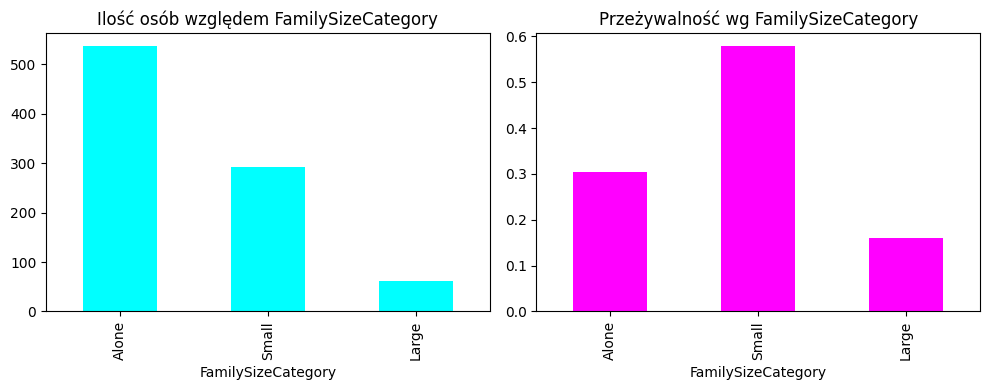

In [253]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
titanic_df['FamilySizeCategory'].value_counts().plot(kind='bar', ax=axes[0], color='cyan')
axes[0].set_title('Ilość osób względem FamilySizeCategory')

titanic_df.groupby('FamilySizeCategory', observed=True)['Survived'].mean().plot(kind='bar', ax=axes[1], color='magenta')
axes[1].set_title('Przeżywalność wg FamilySizeCategory')
plt.tight_layout()
plt.show()

### Zmiana `Sex` na kodowanie binarne
**`Sex` => kodowanie binarne:** `male=0`, `female=1`


In [254]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

In [255]:
titanic_df['Sex'].value_counts()

,count
Sex,
0,577
1,314


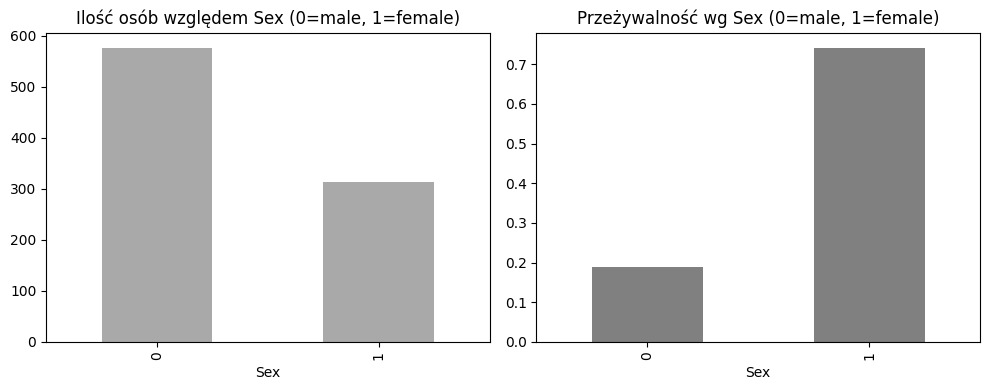

In [256]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
titanic_df['Sex'].value_counts().plot(kind='bar', ax=axes[0], color='darkgrey')
axes[0].set_title('Ilość osób względem Sex (0=male, 1=female)')

titanic_df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1], color='grey')
axes[1].set_title('Przeżywalność wg Sex (0=male, 1=female)')
plt.tight_layout()
plt.show()

### Przetwarzanie `Embarked`
Na samym początku sprawdzam ilość danych i czy nie ma pustych komurek

In [257]:
titanic_df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [258]:
titanic_df['Embarked'].isna().sum()

np.int64(2)

Po znalezieniu brakujących pozycji usupełniem je danymi z najczęściej występującymi danymi ponieważ ich liczba nie ma dużego znaczenie w kontekście ilości całości danych.

In [259]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

Ponieważ `Embarked` to zmienna nominalna przez co porty C, Q, S nie mają naturalnej kolejności, koduję ją metodą one-hot za pomocą `pd.get_dummies`.

In [260]:
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], prefix='Embarked')

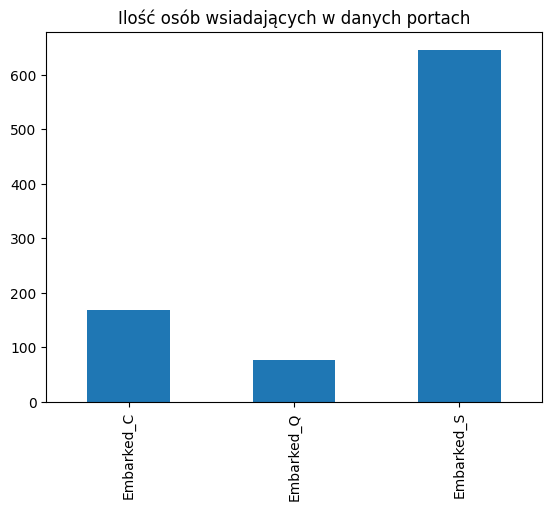

In [261]:
embarked_cols = ['Embarked_C', 'Embarked_Q', 'Embarked_S']
titanic_df[embarked_cols].sum().plot(kind='bar')
plt.title('Ilość osób wsiadających w danych portach')
plt.show()

### Przetwarzanie `Cabin`
Podczas analizy danych zwróciłem uwagę na to czy `Cabin` ma związek z przeżywalnością pasażerów. W tym cely sprawdziłem jak dane kabiny mają się względem przeżywalności i klas biletów. Po ponirzszym sprawdzeniu doszedłem do wniosku, że litery pokładu w dużej mierze duplikują `Pclass` co można zauwarzyć w poniższych tabelach. Natomiast sam fakt przypisania kabiny okazał się jednak niezależnym predyktorem przeżywalności w obrębie każdej klasy. w związku z tym zmodyfikowałem zastópiłem `Cabin` na binarna `HasCabin` (1 = przypisana kabina, 0 = brak).

In [262]:
deck = titanic_df['Cabin'].str[0]

# Liczebność liter pokładu względem klasy biletu
pd.crosstab(deck, titanic_df['Pclass'], dropna=False)

Pclass,1,2,3
Cabin,,,
A,15,0,0
B,47,0,0
C,59,0,0
D,29,4,0
E,25,4,3
F,0,8,5
G,0,0,4
T,1,0,0
NaN,40,168,479


In [263]:
cabin_known = titanic_df['Cabin'].notna()

titanic_df.groupby([titanic_df['Pclass'], cabin_known])['Survived'].mean()

Pclass  Cabin
1       False    0.475000
        True     0.664773
2       False    0.440476
        True     0.812500
3       False    0.235908
        True     0.500000
Name: Survived, dtype: float64

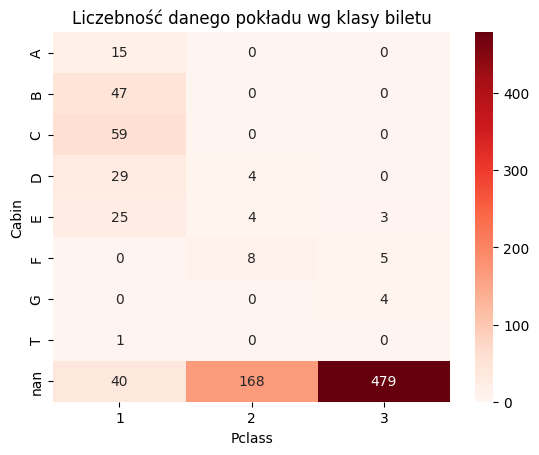

In [264]:
sns.heatmap(pd.crosstab(deck, titanic_df['Pclass'], dropna=False), annot=True, fmt='d', cmap='Reds')
plt.title('Liczebność danego pokładu wg klasy biletu')
plt.show()

In [265]:
titanic_df['HasCabin'] = titanic_df['Cabin'].notna().astype(int)
titanic_df = titanic_df.drop(columns=['Cabin'])

titanic_df.groupby('HasCabin')['Survived'].agg(['mean', 'count'])

,mean,count
HasCabin,,
0,0.299854,687
1,0.666667,204


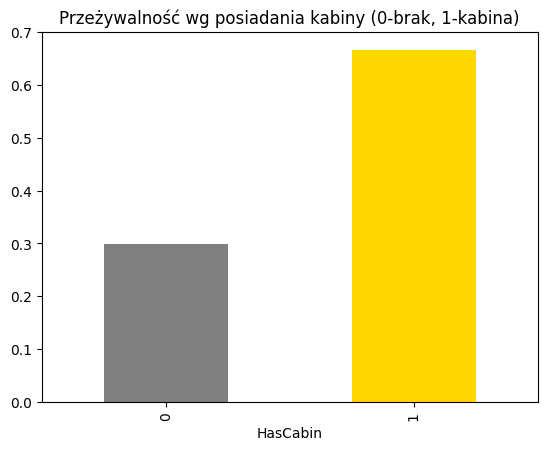

In [266]:
titanic_df.groupby('HasCabin')['Survived'].mean().plot(kind='bar', color=['gray','gold'])
plt.title('Przeżywalność wg posiadania kabiny (0-brak, 1-kabina)')
plt.show()

## Przetwarzanie kolumn `Ticket` i `Fare`

Zwróciłem uwagę, że numer biletu może wskazywać pasażerów podróżujących wspólnie. Dzięki temu mogłem sklasyfikować wielkości grupy biletowej co pozwoliło mi uzupełnie brakujących cen biletów.


`TicketGroupSize`, określa liczbę pasażerów posiadających ten sam numer biletu, co umożliwia wykrycie grup podróżujących razem, również wtedy, gdy nie są one opisane przez relacje `SibSp` i `Parch`.

In [267]:
ticket_counts = titanic_df['Ticket'].value_counts()
titanic_df['TicketGroupSize'] = titanic_df['Ticket'].map(ticket_counts)

titanic_df.groupby('TicketGroupSize')['Survived'].agg(['mean', 'count'])

,mean,count
TicketGroupSize,,
1,0.297989,547
2,0.574468,188
3,0.698413,63
4,0.500000,44
5,0.000000,10
6,0.000000,18
7,0.238095,21


Po przeanalizowaniu ilości osób wynika, że kolumna `Fare` zawiera 98 braków. W tym celu próbuję odzyskać cenę od innych osób z tym samym biletem, ponieważ jak można zauważyć w zbiorze danych istnieje zależność niędzy `Fare` a `Ticket`.

In [268]:
titanic_df['Fare'].isna().sum()

np.int64(98)

In [269]:
titanic_df['Fare'] = titanic_df.groupby('Ticket')['Fare'].transform(lambda x: x.fillna(x.median()))

titanic_df['Fare'].isna().sum()

np.int64(64)

In [270]:
titanic_df = titanic_df.drop(columns=['Ticket'])

Po przeprowadzeniu poprzedniej operacji pozostają braki dla pasażerów, których grupa biletowa nie zawiera znanej ceny. Uzupełniam je medianą `Fare` w obrębie tej samej klasy podróży `Pclass`, ponieważ można zauwarzyć, że cena biletu silnie zależy od klasy.

In [271]:
titanic_df['Fare'] = titanic_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

titanic_df['Fare'].isna().sum()

np.int64(0)

`FarePerPerson`- cena biletu podzielona przez liczbę pasażerów z tym samym numerem `Ticket`, pozwala odróżnić wysoką cenę biletu grupowego od rzeczywistego kosztu przypadającego na jednego pasażera.

In [272]:
titanic_df['FarePerPerson'] = titanic_df['Fare'] / titanic_df['TicketGroupSize']

Sprawdzam skośność `Fare` i `FarePerPerson`, a także liczbę wartości odstających metodą IQR. Jest to potrzebne, ponieważ ceny biletów mogą mieć silnie prawostronnie skośny rozkład: większość biletów jest relatywnie tania, a niewielka liczba bardzo drogich biletów znacząco podnosi maksimum i średnią.

Zastosowałem transformację `log1p` na `Fare` i `FarePerPerson`, aby zmniejszyć wpływ wykrytych wartości odstających. Wybrałem `log1p` zamiast zwykłego `log`, ponieważ część pasażerów miała `Fare = 0` (np. załoga), a logarytm z zera jest niezdefiniowany. Zastosowanie `log1p(0) = 0` rozwiązuje ten problem bez modyfikowania tych wierszy. Po transformacji skośność spadła z ~4.75 do ~0.43 na `Fare_log` i z ~4.17 do ~0.42 na `FarePerPerson_log`, a liczba outlierów wykrywanych metodą IQR wyraźnie się zmniejszyła. Oryginalne kolumny zachowuję równolegle z wersjami `_log`, aby móc porównać ich wpływ na model przed finalnym wyborem cech.

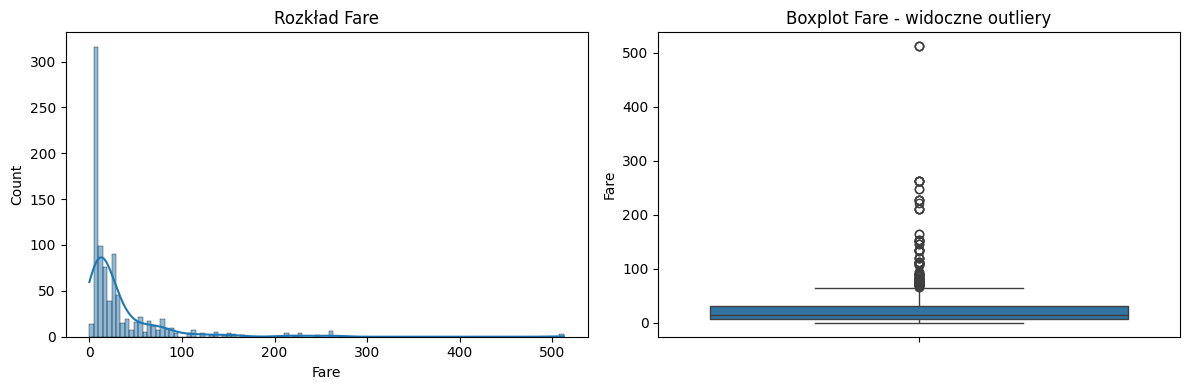

In [273]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(titanic_df['Fare'], kde=True, ax=axes[0])
axes[0].set_title('Rozkład Fare')
sns.boxplot(y=titanic_df['Fare'], ax=axes[1])
axes[1].set_title('Boxplot Fare - widoczne outliery')
plt.tight_layout()
plt.show()

In [274]:
titanic_df['Fare_log'] = np.log1p(titanic_df['Fare'])
titanic_df['FarePerPerson_log'] = np.log1p(titanic_df['FarePerPerson'])

print("Skośność przed transformacją:")
print("Fare:", titanic_df['Fare'].skew())
print("FarePerPerson:", titanic_df['FarePerPerson'].skew())

print("\n Skośność po transformacji:")
print("Fare_log:", titanic_df['Fare_log'].skew())
print("FarePerPerson_log:", titanic_df['FarePerPerson_log'].skew())

print("\n Liczba outlierów (IQR) po transformacji:")
print("Fare_log: ", count_outliers_iqr(titanic_df['Fare_log']))
print("FarePerPerson_log: ", count_outliers_iqr(titanic_df['FarePerPerson_log']))

Skośność przed transformacją:
Fare: 4.754320851747119
FarePerPerson: 4.169536155857523

 Skośność po transformacji:
Fare_log: 0.4348554532516328
FarePerPerson_log: 0.42426749873625225

 Liczba outlierów (IQR) po transformacji:
Fare_log:  29
FarePerPerson_log:  18


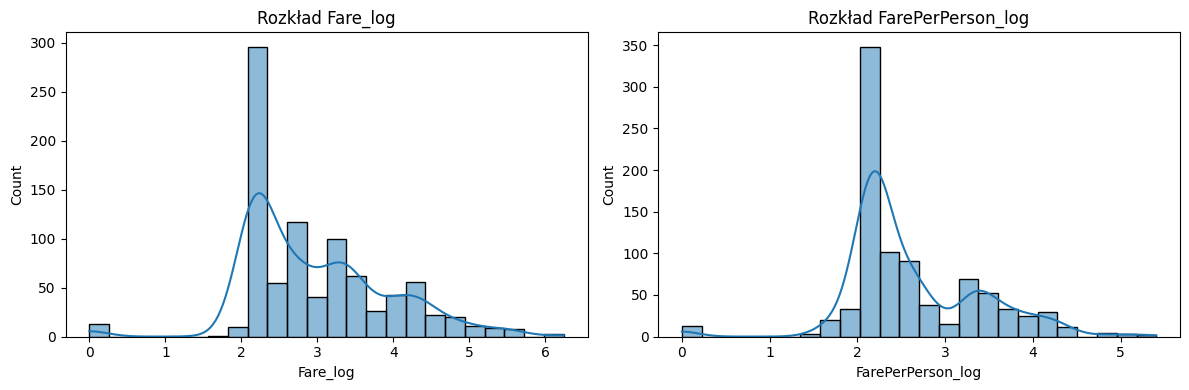

In [275]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(titanic_df['Fare_log'], kde=True, ax=axes[0])
axes[0].set_title('Rozkład Fare_log')
sns.histplot(titanic_df['FarePerPerson_log'], kde=True, ax=axes[1])
axes[1].set_title('Rozkład FarePerPerson_log')
plt.tight_layout()
plt.show()

### Finalne sprawdzenie występowania braków w komurkach

In [276]:
missing_summary = titanic_df.isna().sum()
print("Braki w poszczególnych kolumnach:")
print(missing_summary)
print(f"\n Całkowita liczba brakujących wartości w zbiorze: {missing_summary.sum()}")

Braki w poszczególnych kolumnach:
Survived                     0
Pclass                       0
Sex                          0
Age                          0
Fare                         0
SocialStatus_Capt            0
SocialStatus_Col             0
SocialStatus_Don             0
SocialStatus_Dr              0
SocialStatus_Jonkheer        0
SocialStatus_Lady            0
SocialStatus_Major           0
SocialStatus_Master          0
SocialStatus_Miss            0
SocialStatus_Mr              0
SocialStatus_Mrs             0
SocialStatus_Rev             0
SocialStatus_Sir             0
SocialStatus_the Countess    0
FamilySizeCategory           0
Embarked_C                   0
Embarked_Q                   0
Embarked_S                   0
HasCabin                     0
TicketGroupSize              0
FarePerPerson                0
Fare_log                     0
FarePerPerson_log            0
dtype: int64

 Całkowita liczba brakujących wartości w zbiorze: 0


### Finalny zbiór

In [277]:
print(f"Finalna liczba kolumn: {titanic_df.shape[1]}")
print(f"Finalna liczba wierszy: {titanic_df.shape[0]}")

titanic_df.info()

Finalna liczba kolumn: 28
Finalna liczba wierszy: 891
<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Survived                   891 non-null    int64   
 1   Pclass                     891 non-null    int64   
 2   Sex                        891 non-null    int64   
 3   Age                        891 non-null    float64 
 4   Fare                       891 non-null    float64 
 5   SocialStatus_Capt          891 non-null    bool    
 6   SocialStatus_Col           891 non-null    bool    
 7   SocialStatus_Don           891 non-null    bool    
 8   SocialStatus_Dr            891 non-null    bool    
 9   SocialStatus_Jonkheer      891 non-null    bool    
 10  SocialStatus_Lady          891 non-null    bool    
 11  SocialStatus_Major         891 non-null    bool    
 12  SocialStatus_Master        891 non-null    